# Backward Stepwise Selection

In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

RANDOM_SEED = 42

np.random.seed(RANDOM_SEED)

## 1. Load data

In [16]:
diabetes = load_diabetes(as_frame=True)

X = diabetes.data
y = diabetes.target

df = pd.DataFrame(
    X,
    columns=load_diabetes().feature_names
)

print(f"Dataset shape: {df.shape}")
print(df.head())

Dataset shape: (442, 10)
        age       sex       bmi        bp        s1        s2        s3  \
0  0.038076  0.050680  0.061696  0.021872 -0.044223 -0.034821 -0.043401   
1 -0.001882 -0.044642 -0.051474 -0.026328 -0.008449 -0.019163  0.074412   
2  0.085299  0.050680  0.044451 -0.005670 -0.045599 -0.034194 -0.032356   
3 -0.089063 -0.044642 -0.011595 -0.036656  0.012191  0.024991 -0.036038   
4  0.005383 -0.044642 -0.036385  0.021872  0.003935  0.015596  0.008142   

         s4        s5        s6  
0 -0.002592  0.019907 -0.017646  
1 -0.039493 -0.068332 -0.092204  
2 -0.002592  0.002861 -0.025930  
3  0.034309  0.022688 -0.009362  
4 -0.002592 -0.031988 -0.046641  


## 2. Split dataset

In [17]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=RANDOM_SEED,
)


print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

X_train shape: (353, 10)
X_test shape: (89, 10)
y_train shape: (353,)
y_test shape: (89,)


## 3. Implement Backward Stepwise Selection

**Algorithm**:

1. let $M_p$ denote the full model, which contains all p predictors.
2. For $k=p,p-1,\dots,1$:
    - Consider all $k$ models that contain all but one of the predictors in $M_k$, for a total of $k-1$ predictors.
    - Choose the best among these $k$ models, and call it $M_{k-1}$. Here $best$ is defined as having smallest RSS or highest $R^2$.
3. Select a single best model from among $M_0,\dots,M_p$ using the prediction error on a validation set, $C_p$ (AIC), BIC, adjusted $R^2$. Or use the cross-validation method.

In [18]:
results = []

remaining_features = list(X_train.columns)

while len(remaining_features) > 1:

    candidates = []

    for feature in remaining_features:

        current_features = [
            f for f in remaining_features
            if f != feature
        ]

        model = LinearRegression()
        model.fit(X_train[current_features], y_train)

        y_pred = model.predict(X_train[current_features])

        rss = np.sum((y_train - y_pred) ** 2)

        candidates.append(
            (rss, feature, current_features)
        )

    best_rss, feature_to_remove, best_features = min(
        candidates,
        key=lambda x: x[0]
    )

    remaining_features.remove(feature_to_remove)

    results.append(
        (
            best_rss,
            remaining_features.copy()
        )
    )

In [19]:
for i, result in enumerate(results, start=1):
    print(f"({i}) RSS: {result[0]}, {result[1]}")

(1) RSS: 1013490.0819656126, ['sex', 'bmi', 'bp', 's1', 's2', 's3', 's4', 's5', 's6']
(2) RSS: 1015027.3246336153, ['sex', 'bmi', 'bp', 's1', 's2', 's4', 's5', 's6']
(3) RSS: 1016695.1037401557, ['sex', 'bmi', 'bp', 's1', 's2', 's4', 's5']
(4) RSS: 1022172.2639890872, ['sex', 'bmi', 'bp', 's1', 's2', 's5']
(5) RSS: 1053574.059740825, ['bmi', 'bp', 's1', 's2', 's5']
(6) RSS: 1074425.5272317054, ['bmi', 'bp', 's1', 's5']
(7) RSS: 1108649.5035964558, ['bmi', 'bp', 's5']
(8) RSS: 1161834.7519467813, ['bmi', 's5']
(9) RSS: 1360501.7661827644, ['bmi']


9
range(1, 10)


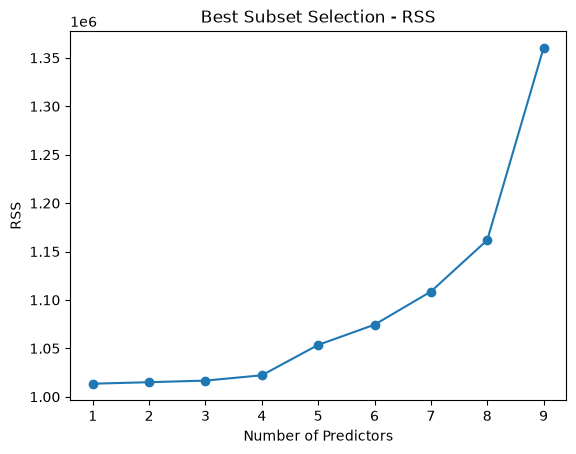

In [20]:
rss_values = [x[0] for x in results]
print(len(rss_values))
model_sizes = range(1, len(results) + 1)
print(model_sizes)

plt.plot(model_sizes, rss_values, marker="o")
plt.xlabel("Number of Predictors")
plt.ylabel("RSS")
plt.title("Best Subset Selection - RSS")
plt.show();

In [21]:
def r_squared(y, y_pred):
    # Calculate Residual sum of squares
    ss_res = np.sum((y - y_pred) ** 2)

    # calculate total sum of squares
    ss_tot = np.sum((y - np.mean(y)) ** 2)

    r_squared_val = 1 - (ss_res / ss_tot)

    return r_squared_val

In [22]:
def adjusted_r_squared(y, y_pred, k):
    n = y.shape[0]
    return 1 - ((1 - r_squared(y, y_pred)) * (n - 1)) / (n - k - 1)

In [31]:
results = []

remaining_features = list(X_train.columns)

while len(remaining_features) > 1:

    candidates = []

    for feature in remaining_features:

        current_features = [
            f for f in remaining_features
            if f != feature
        ]

        model = LinearRegression()
        model.fit(X_train[current_features], y_train)

        y_pred = model.predict(X_train[current_features])

        rss = np.sum((y_train - y_pred) ** 2)

        adj_r2 = adjusted_r_squared(
            y_train,
            y_pred,
            k=len(current_features)
        )

        candidates.append(
            (rss, adj_r2, feature, current_features)
        )

    best_rss, best_adj_r2, feature_to_remove, best_features = min(
        candidates,
        key=lambda x: x[0]
    )

    remaining_features.remove(feature_to_remove)

    results.append(
        (
            best_rss,
            best_adj_r2,
            remaining_features.copy()
        )
    )

In [33]:
for rss, adj_r2, features in results:
    print(
        f"k={len(features)}, "
        f"RSS={rss:.2f}, "
        f"Adjusted R²={adj_r2:.4f}, "
        f"Features={features}"
    )

k=9, RSS=1013490.08, Adjusted R²=0.5151, Features=['sex', 'bmi', 'bp', 's1', 's2', 's3', 's4', 's5', 's6']
k=8, RSS=1015027.32, Adjusted R²=0.5158, Features=['sex', 'bmi', 'bp', 's1', 's2', 's4', 's5', 's6']
k=7, RSS=1016695.10, Adjusted R²=0.5164, Features=['sex', 'bmi', 'bp', 's1', 's2', 's4', 's5']
k=6, RSS=1022172.26, Adjusted R²=0.5152, Features=['sex', 'bmi', 'bp', 's1', 's2', 's5']
k=5, RSS=1053574.06, Adjusted R²=0.5017, Features=['bmi', 'bp', 's1', 's2', 's5']
k=4, RSS=1074425.53, Adjusted R²=0.4933, Features=['bmi', 'bp', 's1', 's5']
k=3, RSS=1108649.50, Adjusted R²=0.4787, Features=['bmi', 'bp', 's5']
k=2, RSS=1161834.75, Adjusted R²=0.4552, Features=['bmi', 's5']
k=1, RSS=1360501.77, Adjusted R²=0.3639, Features=['bmi']


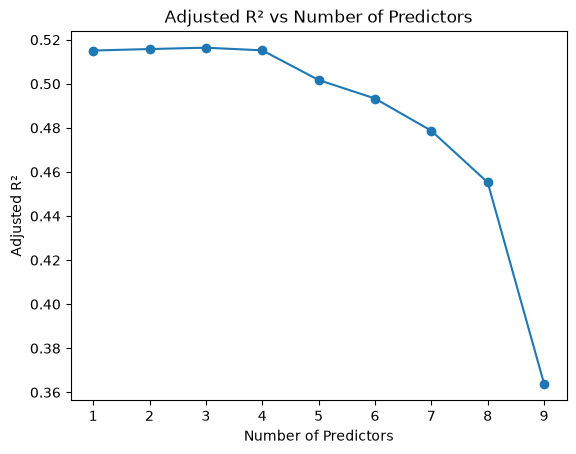

In [34]:
adj_r2_values = [result[1] for result in results]

plt.plot(
    range(1, len(results) + 1),
    adj_r2_values,
    marker="o"
)

plt.xlabel("Number of Predictors")
plt.ylabel("Adjusted R²")
plt.title("Adjusted R² vs Number of Predictors")

plt.show()